=== УСТАНОВКА И ИМПОРТ БИБЛИОТЕК ===

=== СКАЧИВАЕМ ДАТАСЕТ С KAGGLE ===
Path: C:\Users\uzer\.cache\kagglehub\datasets\anishdabhane\apple-tweets-sentiment-dataset\versions\1
Файл найден: C:\Users\uzer\.cache\kagglehub\datasets\anishdabhane\apple-tweets-sentiment-dataset\versions\1\Apple.csv

=== ПРИМЕР ДАННЫХ ===
   sentiment                                               text
0        0.0        #aapl:the 10 best steve jobs emails ever...
1        0.0  rt @jpdesloges: why aapl stock had a mini-flas...
2        0.0  my cat only chews @apple cords. such an #apple...
3        0.0  i agree with @jimcramer that the #individualin...
4        0.0       nobody expects the spanish inquisition #aapl

=== РАСПРЕДЕЛЕНИЕ НАСТРОЕНИЙ ===
sentiment
 0.0    3229
-1.0    2077
 1.0     640
Name: count, dtype: int64


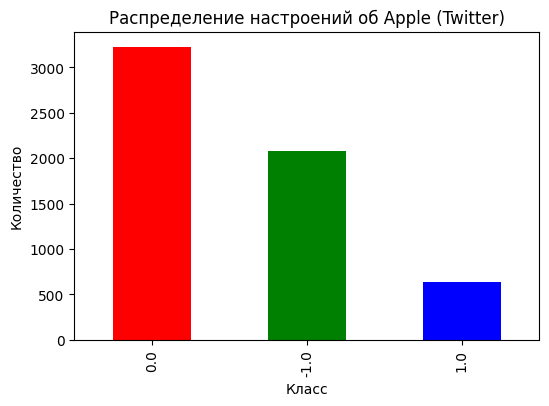

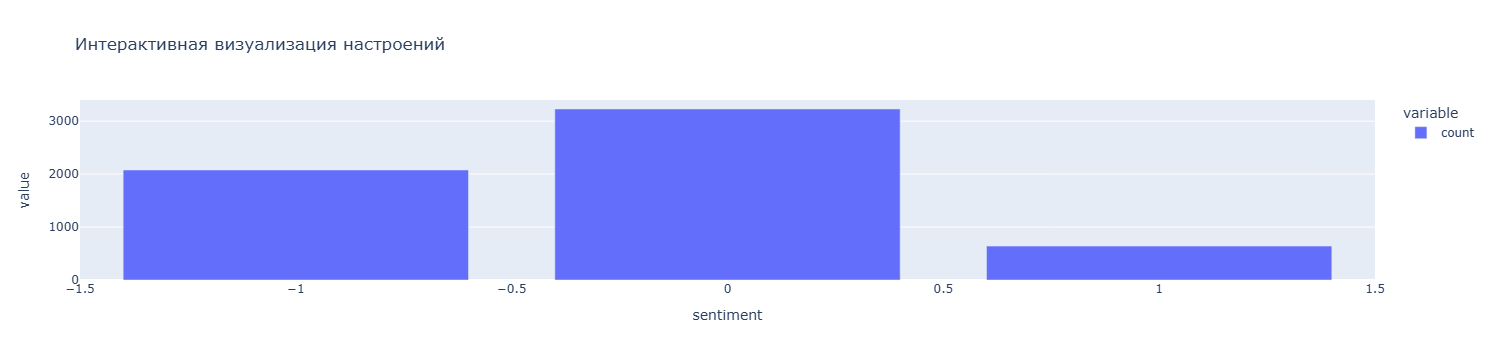


=== МОДЕЛЬ 1: NAIVE BAYES ===
              precision    recall  f1-score   support

        -1.0       0.75      0.77      0.76       429
         0.0       0.76      0.89      0.82       638
         1.0       1.00      0.07      0.12       123

    accuracy                           0.76      1190
   macro avg       0.84      0.57      0.57      1190
weighted avg       0.78      0.76      0.73      1190


=== МОДЕЛЬ 2: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

        -1.0       0.78      0.74      0.76       429
         0.0       0.77      0.89      0.83       638
         1.0       0.87      0.33      0.47       123

    accuracy                           0.78      1190
   macro avg       0.81      0.65      0.69      1190
weighted avg       0.79      0.78      0.77      1190


=== СРАВНЕНИЕ МОДЕЛЕЙ ===
                Модель  Accuracy  F1 Macro
0          Naive Bayes  0.759664  0.567398
1  Logistic Regression  0.779832  0.687641


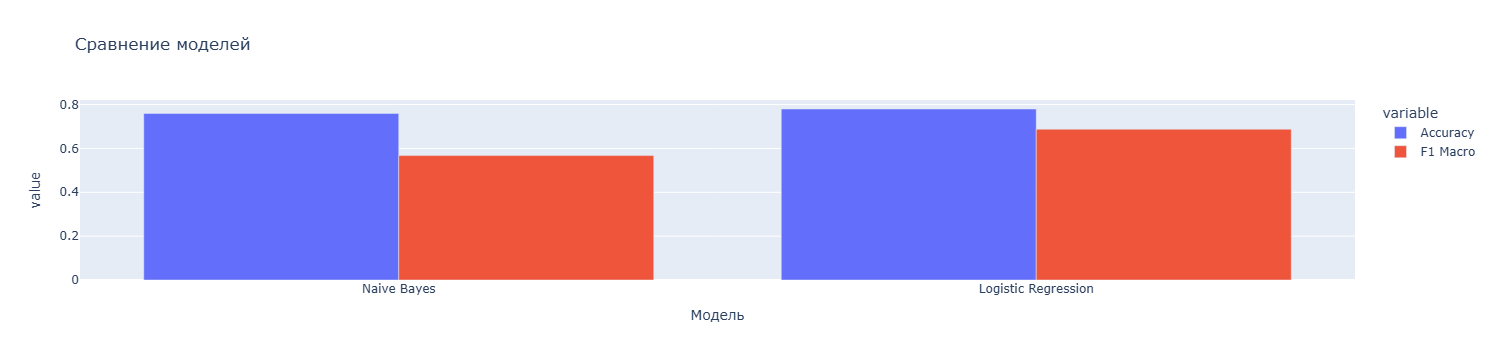


=== АНАЛИЗ ОШИБОК Logistic Regression ===
                                                   text  true  pred
4015        def gotta have it i don t even like watches   1.0   0.0
1726  hey how about you teach your people how to use...   0.0  -1.0
2418  you can already leave snap video messages in a...  -1.0   0.0
2571  aapl slide opens opportunity can t fill iphone...  -1.0   0.0
1533  i ll take a look at that i m fed up with ipad ...  -1.0   0.0
2145  mobile companies really need to learn from the...   1.0   0.0
5240  is it just me or is the americascup battle mir...   0.0  -1.0

=== WORDCLOUD ===
Найденные классы: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


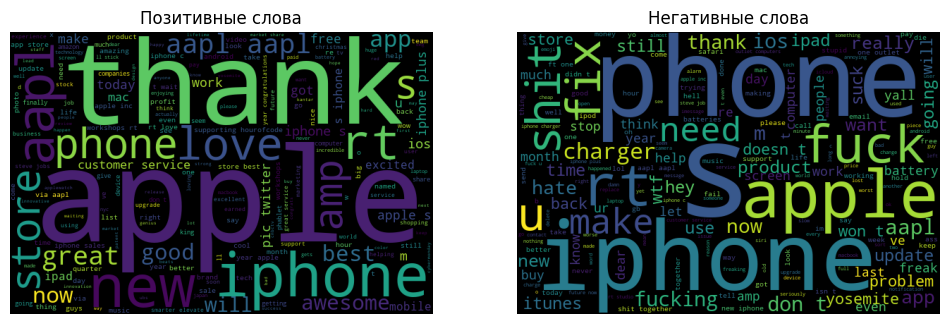


=== ГОТОВО ===
✔ Датасет загружен
✔ Предобработка выполнена
✔ Обучены 2 модели
✔ Построены графики + интерактив
✔ Анализ ошибок есть
✔ WordCloud исправлен и работает


In [9]:

print("=== УСТАНОВКА И ИМПОРТ БИБЛИОТЕК ===")

# установка нужных библиотек
try:
    import kagglehub
except:
    !pip install kagglehub
    import kagglehub

try:
    from wordcloud import WordCloud
except:
    !pip install wordcloud
    from wordcloud import WordCloud

try:
    import plotly.express as px
except:
    !pip install plotly
    import plotly.express as px

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# ==============================
# 1) Загрузка данных
# ==============================

print("\n=== СКАЧИВАЕМ ДАТАСЕТ С KAGGLE ===")
path = kagglehub.dataset_download("anishdabhane/apple-tweets-sentiment-dataset")
print("Path:", path)

files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_path = os.path.join(path, files[0])

print("Файл найден:", csv_path)

df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")
df = df.rename(columns={"tweets":"text", "labels":"sentiment"})

print("\n=== ПРИМЕР ДАННЫХ ===")
print(df.head())

# ==============================
# 2) Предобработка текста
# ==============================

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"@\S+", "", t)
    t = re.sub(r"#", "", t)
    t = re.sub(r"[^a-zA-Z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean_text"] = df["text"].apply(clean_text)

# ==============================
# 3) Базовой анализ
# ==============================

print("\n=== РАСПРЕДЕЛЕНИЕ НАСТРОЕНИЙ ===")
print(df["sentiment"].value_counts())

plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar", color=["red","green","blue"])
plt.title("Распределение настроений об Apple (Twitter)")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

fig = px.bar(df["sentiment"].value_counts(), title="Интерактивная визуализация настроений")
fig.show()

# ==============================
# 4) Train / Test split
# ==============================

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5) Модель 1 — Naive Bayes
# ==============================

print("\n=== МОДЕЛЬ 1: NAIVE BAYES ===")

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("nb", MultinomialNB())
])

nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print(classification_report(y_test, nb_pred))

# ==============================
# 6) Модель 2 — Logistic Regression
# ==============================

print("\n=== МОДЕЛЬ 2: LOGISTIC REGRESSION ===")

lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("lr", LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print(classification_report(y_test, lr_pred))

# ==============================
# 7) Сравнение моделей
# ==============================

acc_nb = accuracy_score(y_test, nb_pred)
acc_lr = accuracy_score(y_test, lr_pred)

f1_nb = f1_score(y_test, nb_pred, average="macro")
f1_lr = f1_score(y_test, lr_pred, average="macro")

compare = pd.DataFrame({
    "Модель": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [acc_nb, acc_lr],
    "F1 Macro": [f1_nb, f1_lr]
})

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(compare)

fig2 = px.bar(compare, x="Модель", y=["Accuracy","F1 Macro"],
              barmode="group", title="Сравнение моделей")
fig2.show()

# ==============================
# 8) Анализ ошибок
# ==============================

print("\n=== АНАЛИЗ ОШИБОК Logistic Regression ===")
errors = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": lr_pred
})
mistakes = errors[errors["true"] != errors["pred"]].head(7)
print(mistakes)

# ==============================
# 9) WordCloud (исправленный)
# ==============================

print("\n=== WORDCLOUD ===")

labels_unique = sorted(df["sentiment"].unique())
print("Найденные классы:", labels_unique)

neg_label = labels_unique[0]
pos_label = labels_unique[-1]

pos = " ".join(df[df["sentiment"]==pos_label]["clean_text"])
neg = " ".join(df[df["sentiment"]==neg_label]["clean_text"])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Позитивные слова")
if len(pos.strip()) > 0:
    plt.imshow(WordCloud(width=600, height=400).generate(pos))
else:
    plt.text(0.3,0.5,"НЕТ ДАННЫХ",fontsize=20)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Негативные слова")
if len(neg.strip()) > 0:
    plt.imshow(WordCloud(width=600, height=400).generate(neg))
else:
    plt.text(0.3,0.5,"НЕТ ДАННЫХ",fontsize=20)
plt.axis("off")

plt.show()

print("\n=== ГОТОВО ===")
print("✔ Датасет загружен")
print("✔ Предобработка выполнена")
print("✔ Обучены 2 модели")
print("✔ Построены графики + интерактив")
print("✔ Анализ ошибок есть")
print("✔ WordCloud исправлен и работает")

